### 1. LOAD DATASETS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

In [2]:
data_dir = Path('.')
csv_files = sorted(data_dir.glob('*.csv'))

print(f"Found {len(csv_files)} CSV files in {data_dir}/")
for f in csv_files:
    print(' -', f.name)

# Select file
csv_file1 = csv_files[0]
csv_file2 = csv_files[1]


df1 = pd.read_csv(csv_file1)
df2 = pd.read_csv(csv_file2)


print(f"\nLoaded {len(df1)} rows from {csv_file1.name}")
print("Columns:", df1.columns.tolist())

print(f"\nLoaded {len(df2)} rows from {csv_file2.name}")
print("Columns:", df2.columns.tolist())


# Select one full rotation (one timestamp)

counts1 = df1.groupby('timestamp').size()
counts2 = df2.groupby('timestamp').size()

# Remove small / partial scans

valid_counts1 = counts1[counts1 > 200]
valid_counts2 = counts2[counts2 > 200]

chosen_ts1 = valid_counts1.index[0]
df_scan1 = df1[df1['timestamp'] == chosen_ts1].copy()


chosen_ts2 = valid_counts2.index[0]
df_scan2 = df2[df2['timestamp'] == chosen_ts2].copy()

print(f"\nUsing timestamp: {chosen_ts1}")
print(f"Points in this scan: {len(df_scan1)}")

print(f"\nUsing timestamp: {chosen_ts2}")
print(f"Points in this scan: {len(df_scan2)}")

display(df_scan1.head())
display(df_scan2.head())



Found 2 CSV files in ./
 - 2025.01.01_LargeRoom_BoxesInLine_03.csv
 - 2025.01.01_SmallRoom_Pos_01.csv

Loaded 14915 rows from 2025.01.01_LargeRoom_BoxesInLine_03.csv
Columns: ['timestamp', 'quality', 'angle_deg', 'distance_mm']

Loaded 10913 rows from 2025.01.01_SmallRoom_Pos_01.csv
Columns: ['timestamp', 'quality', 'angle_deg', 'distance_mm']

Using timestamp: 1767277060.117305
Points in this scan: 268

Using timestamp: 1767275341.435938
Points in this scan: 278


,timestamp,quality,angle_deg,distance_mm
98,1.767277e+09,15,352.328125,2055.75
99,1.767277e+09,15,353.531250,2053.00
100,1.767277e+09,15,354.687500,2050.00
101,1.767277e+09,15,355.843750,2047.00
102,1.767277e+09,15,357.000000,2046.50


,timestamp,quality,angle_deg,distance_mm
63,1.767275e+09,15,352.671875,753.50
64,1.767275e+09,15,353.812500,751.75
65,1.767275e+09,15,355.015625,750.50
66,1.767275e+09,15,356.203125,749.50
67,1.767275e+09,15,357.468750,747.25


### FIRST EXPERIMENT

In [3]:

angles_deg = df_scan1["angle_deg"].values
r_mm = df_scan1["distance_mm"].values

r = r_mm / 1000.0  
theta = np.deg2rad(angles_deg)

#  kernel: r' = log(1 + r)
r_prime = np.log(1 + r)

# Convert back to Cartesian for DBSCAN ---
x_prime = r_prime * np.cos(theta)
y_prime = r_prime * np.sin(theta)

points_warped = np.vstack((x_prime, y_prime)).T


In [4]:

db = DBSCAN(eps=0.08, min_samples=4).fit(points_warped)
labels = db.labels_

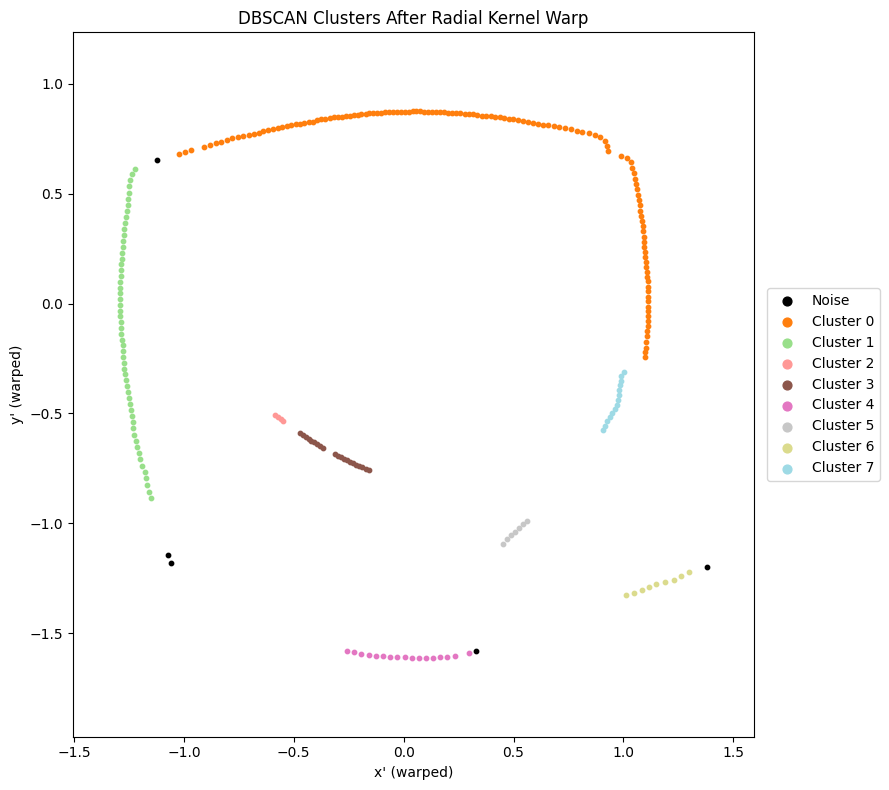

In [5]:

unique_labels = np.unique(labels)

# Build a color map for clusters (skip black)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(9, 8))

for idx, label in enumerate(unique_labels):
    if label == -1:
        # Noise in black
        plt.scatter(
            points_warped[labels == label, 0],
            points_warped[labels == label, 1],
            c="black",
            s=10,
            label="Noise"
        )
    else:
        plt.scatter(
            points_warped[labels == label, 0],
            points_warped[labels == label, 1],
            c=[colors[idx]],
            s=10,
            label=f"Cluster {label}"
        )

plt.title("DBSCAN Clusters After Radial Kernel Warp")
plt.xlabel("x' (warped)")
plt.ylabel("y' (warped)")
plt.axis("equal")

# Move legend to the right
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    markerscale=2,
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### KERNEL EXPERIMENT

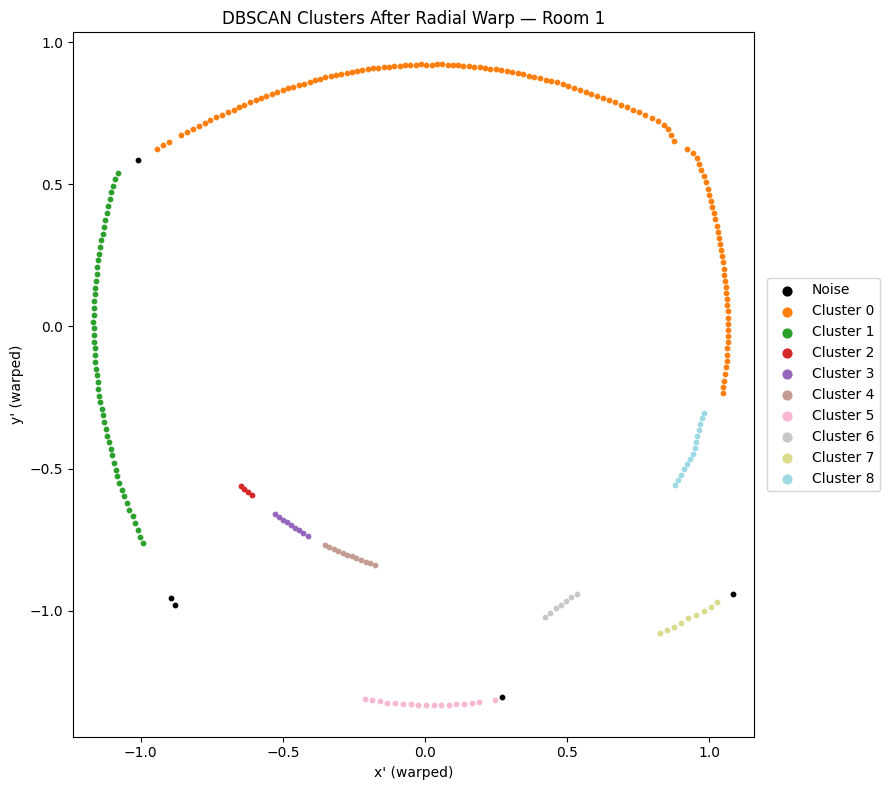

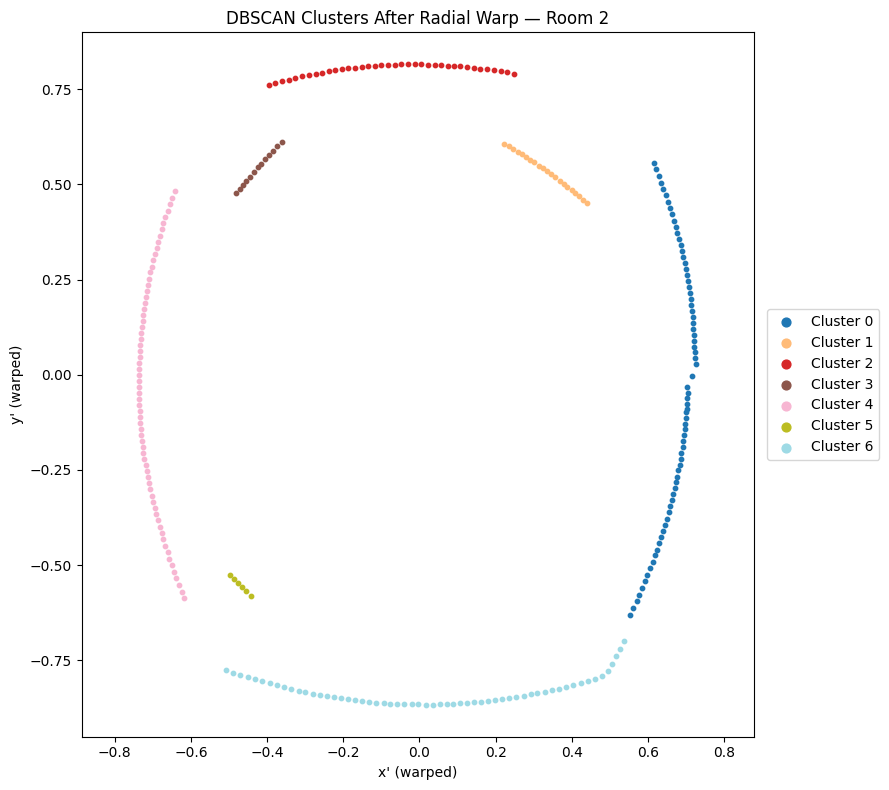

In [ ]:
# Funtion for each room

def process_and_plot(df, title_suffix):
    # Extract polar data 
    angles_deg = df["angle_deg"].values
    r_mm = df["distance_mm"].values

    r = r_mm / 1000.0
    theta = np.deg2rad(angles_deg)

    #KERNEL

    # Radial kernel
    #log

    #r_prime = np.log(1 + r)

    #power

   # alpha = 0.35
   # r_prime = r ** alpha

    #log + power

    alpha = 0.6
    r_prime = np.log1p(r) ** alpha

    # exponetial soft

   # k = 1.2
   #r_prime = 1 - np.exp(-k * r)


    # Adaptive Exponential Kernel
    #r_max = np.max(r)
    #k = 2
    #r_prime = (1 - np.exp(-k * r)) / (1 - np.exp(-k * r_max))


    # Cartesian
    x_prime = r_prime * np.cos(theta)
    y_prime = r_prime * np.sin(theta)
    points_warped = np.vstack((x_prime, y_prime)).T

    # DBSCAN 
    db = DBSCAN(eps=0.06, min_samples=4).fit(points_warped)
    labels = db.labels_
    unique_labels = np.unique(labels)

    # Colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

    # Plot
    plt.figure(figsize=(9, 8))
    for idx, label in enumerate(unique_labels):
        if label == -1:
            plt.scatter(
                points_warped[labels == label, 0],
                points_warped[labels == label, 1],
                c="black",
                s=10,
                label="Noise"
            )
        else:
            plt.scatter(
                points_warped[labels == label, 0],
                points_warped[labels == label, 1],
                c=[colors[idx]],
                s=10,
                label=f"Cluster {label}"
            )

    plt.title(f"DBSCAN Clusters After Radial Warp — {title_suffix}")
    plt.xlabel("x' (warped)")
    plt.ylabel("y' (warped)")
    plt.axis("equal")
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        markerscale=2,
        borderaxespad=0
    )
    plt.tight_layout()
    plt.show()


#  Run for both rooms automatically
process_and_plot(df_scan1, "Room 1")
process_and_plot(df_scan2, "Room 2")